## Part 1 — Data Preprocessing & Exploration

Mahmoud Yasser 14002432
Youssef Khaled Mamdouh 13001870
Chantal Sherif Nabil 13007034

### Load the dataset and inspect splits

In [1]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dair-ai/emotion dataset
dataset = load_dataset('dair-ai/emotion')

print(f"Dataset loaded with splits: {list(dataset.keys())}")

# Report number of examples per split
for split, data in dataset.items():
    print(f"{split.capitalize()} split: {len(data)} examples")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Dataset loaded with splits: ['train', 'validation', 'test']
Train split: 16000 examples
Validation split: 2000 examples
Test split: 2000 examples


### Report basic statistics: class distribution

In [2]:
# Map label integers to emotion names for better readability
def get_label_names(dataset):
    return dataset['train'].features['label'].names

label_names = get_label_names(dataset)

# Report class distribution for each split
for split, data in dataset.items():
    print(f"\nClass distribution for {split.capitalize()} split:")
    labels = pd.Series(data['label'])
    class_counts = labels.map(lambda x: label_names[x]).value_counts().sort_index()
    class_percentages = labels.map(lambda x: label_names[x]).value_counts(normalize=True).sort_index()
    class_df = pd.DataFrame({'Count': class_counts, 'Percentage': class_percentages.apply(lambda x: f'{x:.2%}')})
    display(class_df)


Class distribution for Train split:


,Count,Percentage
anger,2159,13.49%
fear,1937,12.11%
joy,5362,33.51%
love,1304,8.15%
sadness,4666,29.16%
surprise,572,3.57%



Class distribution for Validation split:


,Count,Percentage
anger,275,13.75%
fear,212,10.60%
joy,704,35.20%
love,178,8.90%
sadness,550,27.50%
surprise,81,4.05%



Class distribution for Test split:


,Count,Percentage
anger,275,13.75%
fear,224,11.20%
joy,695,34.75%
love,159,7.95%
sadness,581,29.05%
surprise,66,3.30%


### Report basic statistics: text length distribution

In [3]:
# Calculate text length distribution (in characters)
for split, data in dataset.items():
    print(f"\nText length distribution (characters) for {split.capitalize()} split:")
    text_lengths = [len(text) for text in data['text']]
    lengths_series = pd.Series(text_lengths)
    print(lengths_series.describe().to_string())


Text length distribution (characters) for Train split:
count    16000.000000
mean        96.845812
std         55.904953
min          7.000000
25%         53.000000
50%         86.000000
75%        129.000000
max        300.000000

Text length distribution (characters) for Validation split:
count    2000.000000
mean       95.347500
std        54.823759
min        11.000000
25%        53.000000
50%        85.000000
75%       128.000000
max       295.000000

Text length distribution (characters) for Test split:
count    2000.000000
mean       96.586500
std        55.715991
min        14.000000
25%        52.000000
50%        86.000000
75%       130.000000
max       296.000000


### Visualize class balance and text length

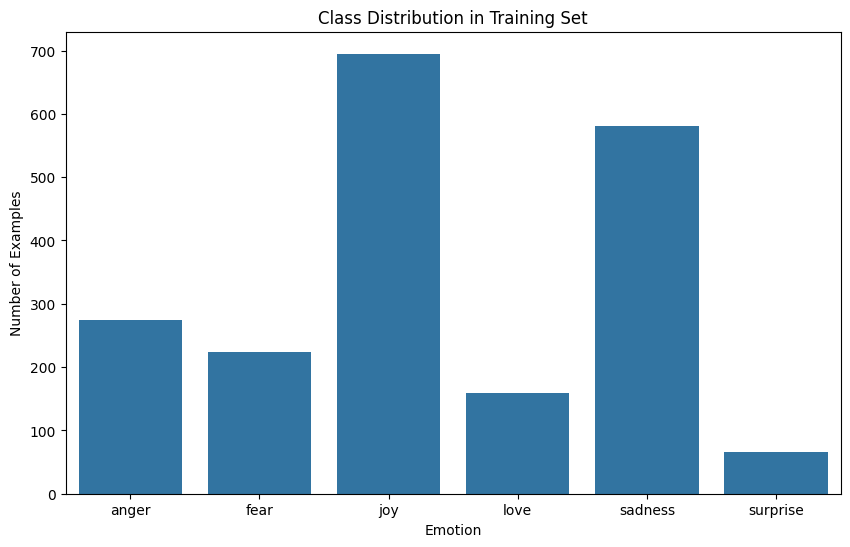

In [4]:
# Visualize class distribution for the training set (as an example, can be extended to all splits)
plt.figure(figsize=(10, 6))
sns.barplot(x=class_df.index, y='Count', data=class_df)
plt.title('Class Distribution in Training Set')
plt.xlabel('Emotion')
plt.ylabel('Number of Examples')
plt.show()

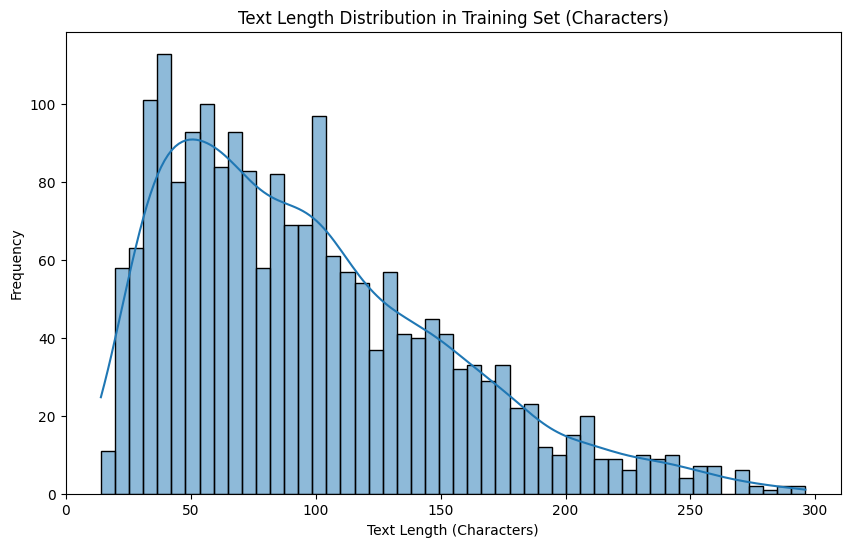

In [5]:
# Visualize text length distribution for the training set (as an example, can be extended to all splits)
plt.figure(figsize=(10, 6))
sns.histplot(lengths_series, bins=50, kde=True)
plt.title('Text Length Distribution in Training Set (Characters)')
plt.xlabel('Text Length (Characters)')
plt.ylabel('Frequency')
plt.show()

### Build two tokenization pipelines

#### Custom Tokenizer for From-Scratch RNN (Part 2)

In [6]:
from collections import Counter

# Combine all text from the training set to build vocabulary
all_train_text = ' '.join(dataset['train']['text'])

# Simple tokenization by splitting on whitespace and converting to lowercase
tokens = all_train_text.lower().split()

# Build vocabulary: assign a unique ID to each unique token
# We will use special tokens for padding (<pad>), unknown (<unk>), and start of sequence (<sos>) if needed
vocab = {'<pad>': 0, '<unk>': 1} # Start with special tokens
word_counts = Counter(tokens)

# Add words to vocabulary based on frequency (e.g., top N words or all words)
# For simplicity, let's add all unique words beyond a minimum frequency
min_freq = 2 # words appearing less than this will be treated as <unk>
for word, count in word_counts.items():
    if count >= min_freq:
        vocab[word] = len(vocab)

# A function to tokenize and convert text to IDs using our custom vocabulary
def custom_tokenize(text, vocab, max_length=None):
    token_ids = []
    for word in text.lower().split():
        token_ids.append(vocab.get(word, vocab['<unk>']))
    if max_length:
        token_ids = token_ids[:max_length]
        while len(token_ids) < max_length:
            token_ids.append(vocab['<pad>'])
    return token_ids

print(f"Custom vocabulary size: {len(vocab)}")
print("Example tokenization for 'i feel fine': ", custom_tokenize('i feel fine', vocab))

# Store the vocabulary for later use
custom_vocab = vocab

Custom vocabulary size: 7401
Example tokenization for 'i feel fine':  [2, 4, 1024]


#### Pretrained Tokenizer for Transformer (Part 3) and LLM (Part 4)

In [7]:
from transformers import AutoTokenizer

# Load a pretrained tokenizer (e.g., 'distilbert-base-uncased')
pretrained_tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

# Example of tokenization using the pretrained tokenizer
sample_text = "I feel so happy today!"
encoded_input = pretrained_tokenizer(sample_text, truncation=True, padding='max_length', max_length=50, return_tensors='pt')

print(f"Pretrained tokenizer: {pretrained_tokenizer.name_or_path}")
print("Example tokenization for 'I feel so happy today!':")
print("Input IDs:", encoded_input['input_ids'][0])
print("Attention Mask:", encoded_input['attention_mask'][0])

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Pretrained tokenizer: distilbert-base-uncased
Example tokenization for 'I feel so happy today!':
Input IDs: tensor([ 101, 1045, 2514, 2061, 3407, 2651,  999,  102,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0])
Attention Mask: tensor([1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0])


### Justify cleaning choices and preprocessing necessity

For this dataset, which consists of short, informal texts (likely tweets), several preprocessing steps are considered:

*   **Lowercasing**: All text is converted to lowercase for both tokenizers. This helps in reducing the vocabulary size and treating words like 'Happy' and 'happy' as the same token, which is generally beneficial for text classification tasks where word meaning is more important than capitalization.

*   **Punctuation Handling**:
    *   For the custom tokenizer, a simple `split()` on whitespace means punctuation attached to words (e.g., 'today!') might be treated as part of the word. A more robust custom tokenizer would involve regular expressions to separate punctuation. However, for a simple RNN baseline, this level of detail might be sufficient to capture basic sentiment.
    *   Pretrained tokenizers (like DistilBERT's) are typically trained with their own specific punctuation handling rules, often involving separating punctuation from words or normalizing it. We rely on the tokenizer's built-in capabilities.

*   **Maximum Sequence Length**:
    *   The `dair-ai/emotion` dataset contains short texts (max length around 300 characters, as observed in the text length distribution). For the custom tokenizer, a `max_length` can be applied during padding. For the pretrained tokenizer, `truncation=True` and `padding='max_length'` with a chosen `max_length` (e.g., 50 or 128) is standard. Given the short nature of the texts, a relatively small `max_length` will likely suffice without much loss of information, while improving computational efficiency.

*   **Other Preprocessing (e.g., Stop Words, Stemming/Lemmatization)**: These steps are generally *not necessary* for this task, especially when using modern transformer models. Pretrained models have learned rich representations that inherently handle such linguistic nuances. For a simple RNN, removing stop words might marginally reduce noise, but can also remove valuable context. Stemming/lemmatization can reduce vocabulary further, but might also lead to loss of specific word meanings crucial for subtle emotion detection. Therefore, for this project, these advanced cleaning steps are generally avoided to allow the models to learn from the raw text data as much as possible.

## Part 2 — Baseline: From-Scratch RNN Classifier

### Data Preparation for RNN

In [8]:
import torch
from torch.utils.data import DataLoader, TensorDataset

# Define a maximum sequence length for the RNN
# This should be chosen based on the text length distribution analysis in Part 1
RNN_MAX_LENGTH = 64 # A reasonable length given the short nature of texts

def prepare_rnn_data(dataset_split, vocab, max_length):
    tokenized_texts = [custom_tokenize(text, vocab, max_length=max_length) for text in dataset_split['text']]
    labels = dataset_split['label']

    # Convert to PyTorch tensors
    input_ids = torch.tensor(tokenized_texts, dtype=torch.long)
    labels = torch.tensor(labels, dtype=torch.long)

    return TensorDataset(input_ids, labels)

# Prepare datasets for each split
train_data = prepare_rnn_data(dataset['train'], custom_vocab, RNN_MAX_LENGTH)
val_data = prepare_rnn_data(dataset['validation'], custom_vocab, RNN_MAX_LENGTH)
test_data = prepare_rnn_data(dataset['test'], custom_vocab, RNN_MAX_LENGTH)

# Define DataLoader parameters
BATCH_SIZE = 64

# Create DataLoaders
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

print(f"RNN training data prepared with {len(train_data)} examples.")
print(f"RNN validation data prepared with {len(val_data)} examples.")
print(f"RNN test data prepared with {len(test_data)} examples.")
print(f"Example of tokenized text (first example, input_ids): {train_data[0][0]}")
print(f"Example of label (first example): {train_data[0][1]}")

RNN training data prepared with 16000 examples.
RNN validation data prepared with 2000 examples.
RNN test data prepared with 2000 examples.
Example of tokenized text (first example, input_ids): tensor([2, 3, 4, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
Example of label (first example): 0


### RNN Model Definition

In [9]:
import torch.nn as nn

class EmotionRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, num_classes, dropout=0.5):
        super(EmotionRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=custom_vocab['<pad>'])
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_size,
            num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0 # Dropout only if num_layers > 1
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, text):
        # text shape: (batch_size, seq_len)
        embedded = self.embedding(text)
        # embedded shape: (batch_size, seq_len, embedding_dim)

        lstm_out, (hidden, cell) = self.lstm(embedded)
        # lstm_out shape: (batch_size, seq_len, hidden_size)
        # hidden shape: (num_layers, batch_size, hidden_size)

        # Use the hidden state of the last layer for classification
        hidden = self.dropout(hidden[-1]) # hidden[-1] is the last layer's hidden state
        logits = self.fc(hidden)
        return logits

# Model Hyperparameters
VOCAB_SIZE = len(custom_vocab)
EMBEDDING_DIM = 100
HIDDEN_SIZE = 128
NUM_LAYERS = 2
NUM_CLASSES = len(label_names) # 6 emotions

# Instantiate the model
rnn_model = EmotionRNN(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_SIZE, NUM_LAYERS, NUM_CLASSES)

# Move model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
rnn_model.to(device)

print(rnn_model)

EmotionRNN(
  (embedding): Embedding(7401, 100, padding_idx=0)
  (lstm): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.5)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=128, out_features=6, bias=True)
)


### Training the RNN

In [10]:
import torch.optim as optim
import time

# Define optimizer and loss function
LEARNING_RATE = 0.001
N_EPOCHS = 10

optimizer = optim.Adam(rnn_model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

def train(model, loader, optimizer, criterion, device):
    model.train()
    epoch_loss = 0
    for batch_idx, (text, labels) in enumerate(loader):
        text, labels = text.to(device), labels.to(device)

        optimizer.zero_grad()
        predictions = model(text)
        loss = criterion(predictions, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
    return epoch_loss / len(loader)

def evaluate(model, loader, criterion, device):
    model.eval()
    epoch_loss = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for text, labels in loader:
            text, labels = text.to(device), labels.to(device)
            predictions = model(text)
            loss = criterion(predictions, labels)
            epoch_loss += loss.item()

            _, predicted_labels = torch.max(predictions, 1)
            all_preds.extend(predicted_labels.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return epoch_loss / len(loader), all_preds, all_labels

# Training loop
train_losses = []
val_losses = []

print(f"Starting RNN training for {N_EPOCHS} epochs...")
train_start_time = time.time()

for epoch in range(N_EPOCHS):
    train_loss = train(rnn_model, train_loader, optimizer, criterion, device)
    val_loss, _, _ = evaluate(rnn_model, val_loader, criterion, device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f'Epoch: {epoch+1:02} | Train Loss: {train_loss:.3f} | Val Loss: {val_loss:.3f}')

train_end_time = time.time()
total_train_time = train_end_time - train_start_time
print(f"RNN training completed in {total_train_time:.2f} seconds.")

Starting RNN training for 10 epochs...
Epoch: 01 | Train Loss: 1.595 | Val Loss: 1.583
Epoch: 02 | Train Loss: 1.581 | Val Loss: 1.582
Epoch: 03 | Train Loss: 1.580 | Val Loss: 1.584
Epoch: 04 | Train Loss: 1.580 | Val Loss: 1.589
Epoch: 05 | Train Loss: 1.579 | Val Loss: 1.585
Epoch: 06 | Train Loss: 1.578 | Val Loss: 1.583
Epoch: 07 | Train Loss: 1.577 | Val Loss: 1.583
Epoch: 08 | Train Loss: 1.584 | Val Loss: 1.583
Epoch: 09 | Train Loss: 1.579 | Val Loss: 1.582
Epoch: 10 | Train Loss: 1.578 | Val Loss: 1.583
RNN training completed in 23.71 seconds.


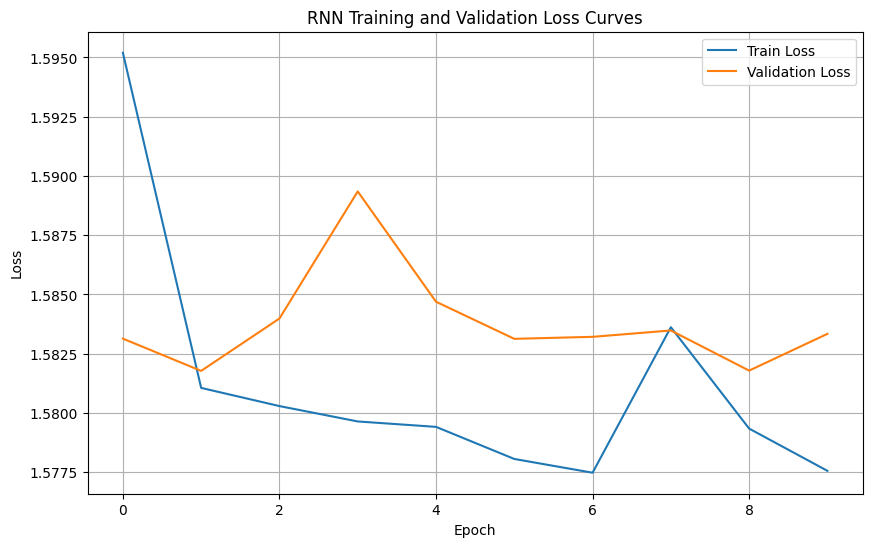

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('RNN Training and Validation Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Evaluation and Metrics

### Addressing RNN Underfitting

The current RNN model appears to be underfitting the data, as evidenced by the very low accuracy and the flat, almost identical training and validation loss curves. This suggests that the model does not have sufficient capacity to learn the patterns in the data, or it hasn't trained for long enough.

To mitigate underfitting, we will increase the model's complexity and training duration:
- **Increase `EMBEDDING_DIM`**: Provide richer word representations.
- **Increase `HIDDEN_SIZE`**: Allow the LSTM layers to capture more complex sequential dependencies.
- **Increase `NUM_LAYERS`**: Enable the model to learn a deeper hierarchy of features.
- **Increase `N_EPOCHS`**: Give the model more opportunities to learn from the data.

In [12]:
# Modified Model Hyperparameters to address underfitting
MOD_EMBEDDING_DIM = 200
MOD_HIDDEN_SIZE = 256
MOD_NUM_LAYERS = 3
MOD_N_EPOCHS = 20 # Increase epochs from 10 to 20
MOD_LEARNING_RATE = 0.001 # Keep learning rate as it is for now

print(f"Updated RNN Hyperparameters:\n  Embedding Dim: {MOD_EMBEDDING_DIM}\n  Hidden Size: {MOD_HIDDEN_SIZE}\n  Number of Layers: {MOD_NUM_LAYERS}\n  Epochs: {MOD_N_EPOCHS}")

Updated RNN Hyperparameters:
  Embedding Dim: 200
  Hidden Size: 256
  Number of Layers: 3
  Epochs: 20


In [13]:
# Re-instantiate the model with updated hyperparameters
mod_rnn_model = EmotionRNN(
    vocab_size=VOCAB_SIZE,
    embedding_dim=MOD_EMBEDDING_DIM,
    hidden_size=MOD_HIDDEN_SIZE,
    num_layers=MOD_NUM_LAYERS,
    num_classes=NUM_CLASSES
)

mod_rnn_model.to(device);

# Re-define optimizer and criterion
mod_optimizer = optim.Adam(mod_rnn_model.parameters(), lr=MOD_LEARNING_RATE)
mod_criterion = nn.CrossEntropyLoss()

print("Re-instantiated RNN model with increased capacity:")
print(mod_rnn_model)

Re-instantiated RNN model with increased capacity:
EmotionRNN(
  (embedding): Embedding(7401, 200, padding_idx=0)
  (lstm): LSTM(200, 256, num_layers=3, batch_first=True, dropout=0.5)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=6, bias=True)
)


In [14]:
# Re-train the RNN model with updated hyperparameters
mod_train_losses = []
mod_val_losses = []

print(f"Starting re-training of RNN for {MOD_N_EPOCHS} epochs with new hyperparameters...")
mod_train_start_time = time.time()

for epoch in range(MOD_N_EPOCHS):
    train_loss = train(mod_rnn_model, train_loader, mod_optimizer, mod_criterion, device)
    val_loss, _, _ = evaluate(mod_rnn_model, val_loader, mod_criterion, device)
    mod_train_losses.append(train_loss)
    mod_val_losses.append(val_loss)

    print(f'Epoch: {epoch+1:02} | Train Loss: {train_loss:.3f} | Val Loss: {val_loss:.3f}')

mod_train_end_time = time.time()
mod_total_train_time = mod_train_end_time - mod_train_start_time
print(f"Re-trained RNN completed in {mod_total_train_time:.2f} seconds.")

Starting re-training of RNN for 20 epochs with new hyperparameters...
Epoch: 01 | Train Loss: 1.589 | Val Loss: 1.583
Epoch: 02 | Train Loss: 1.580 | Val Loss: 1.584
Epoch: 03 | Train Loss: 1.580 | Val Loss: 1.583
Epoch: 04 | Train Loss: 1.580 | Val Loss: 1.582
Epoch: 05 | Train Loss: 1.580 | Val Loss: 1.584
Epoch: 06 | Train Loss: 1.578 | Val Loss: 1.584
Epoch: 07 | Train Loss: 1.579 | Val Loss: 1.583
Epoch: 08 | Train Loss: 1.577 | Val Loss: 1.583
Epoch: 09 | Train Loss: 1.581 | Val Loss: 1.585
Epoch: 10 | Train Loss: 1.576 | Val Loss: 1.585
Epoch: 11 | Train Loss: 1.578 | Val Loss: 1.582
Epoch: 12 | Train Loss: 1.575 | Val Loss: 1.584
Epoch: 13 | Train Loss: 1.570 | Val Loss: 1.581
Epoch: 14 | Train Loss: 1.449 | Val Loss: 1.287
Epoch: 15 | Train Loss: 1.060 | Val Loss: 1.013
Epoch: 16 | Train Loss: 0.793 | Val Loss: 0.761
Epoch: 17 | Train Loss: 0.638 | Val Loss: 0.694
Epoch: 18 | Train Loss: 0.540 | Val Loss: 0.606
Epoch: 19 | Train Loss: 0.398 | Val Loss: 0.509
Epoch: 20 | Train 

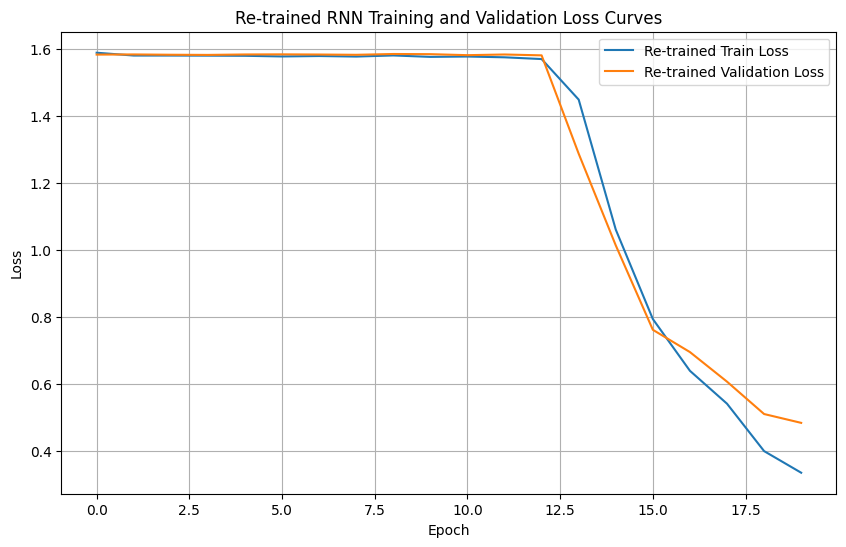

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(mod_train_losses, label='Re-trained Train Loss')
plt.plot(mod_val_losses, label='Re-trained Validation Loss')
plt.title('Re-trained RNN Training and Validation Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

Evaluating re-trained RNN model on the test set...
Re-trained Test Loss: 0.431
Re-trained Test Accuracy: 0.8445
Re-trained Test Macro F1: 0.6818

Re-trained Per-class F1 Score:
  sadness: 0.9046
  joy: 0.9142
  love: 0.5970
  anger: 0.8406
  fear: 0.8344
  surprise: 0.0000

Total Re-trained Training Time: 106.29 seconds
Total Re-trained Inference Time on Test Set: 0.22 seconds


<Figure size 800x600 with 0 Axes>

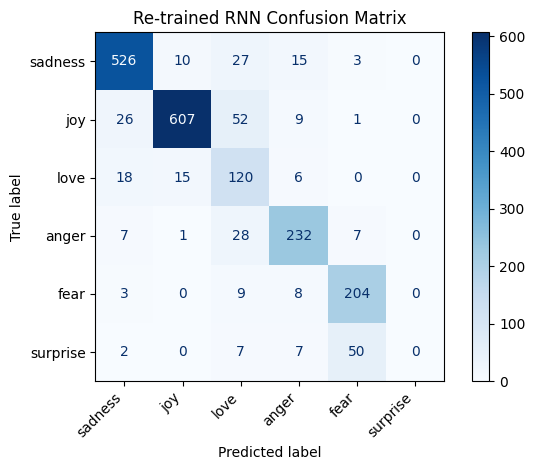

In [16]:
import time
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Evaluating re-trained RNN model on the test set...")
mod_inference_start_time = time.time()

mod_test_loss, mod_test_preds, mod_test_labels = evaluate(mod_rnn_model, test_loader, mod_criterion, device)

mod_inference_end_time = time.time()
mod_total_inference_time = mod_inference_end_time - mod_inference_start_time

mod_accuracy = accuracy_score(mod_test_labels, mod_test_preds)
mod_macro_f1 = f1_score(mod_test_labels, mod_test_preds, average='macro')
mod_per_class_f1 = f1_score(mod_test_labels, mod_test_preds, average=None)

print(f'Re-trained Test Loss: {mod_test_loss:.3f}')
print(f'Re-trained Test Accuracy: {mod_accuracy:.4f}')
print(f'Re-trained Test Macro F1: {mod_macro_f1:.4f}')
print('\nRe-trained Per-class F1 Score:')
for i, f1 in enumerate(mod_per_class_f1):
    print(f'  {label_names[i]}: {f1:.4f}')

print(f'\nTotal Re-trained Training Time: {mod_total_train_time:.2f} seconds')
print(f'Total Re-trained Inference Time on Test Set: {mod_total_inference_time:.2f} seconds')

# Confusion Matrix for re-trained RNN
mod_cm = confusion_matrix(mod_test_labels, mod_test_preds)
plt.figure(figsize=(8, 6))
mod_disp = ConfusionMatrixDisplay(confusion_matrix=mod_cm, display_labels=label_names)
mod_disp.plot(cmap=plt.cm.Blues)
plt.title('Re-trained RNN Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Evaluating RNN model on the test set...
Test Loss: 1.567
Test Accuracy: 0.3465
Test Macro F1: 0.0859

Per-class F1 Score:
  sadness: 0.0000
  joy: 0.5154
  love: 0.0000
  anger: 0.0000
  fear: 0.0000
  surprise: 0.0000

Total Training Time: 23.71 seconds
Total Inference Time on Test Set: 0.07 seconds


<Figure size 800x600 with 0 Axes>

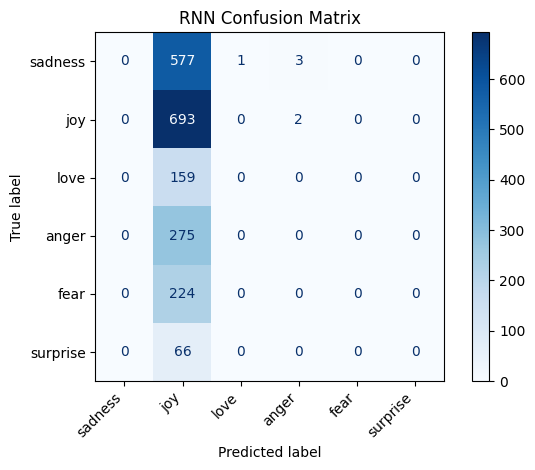

In [17]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

print("Evaluating RNN model on the test set...")
inference_start_time = time.time()

test_loss, test_preds, test_labels = evaluate(rnn_model, test_loader, criterion, device)

inference_end_time = time.time()
total_inference_time = inference_end_time - inference_start_time

accuracy = accuracy_score(test_labels, test_preds)
macro_f1 = f1_score(test_labels, test_preds, average='macro')
per_class_f1 = f1_score(test_labels, test_preds, average=None)

print(f'Test Loss: {test_loss:.3f}')
print(f'Test Accuracy: {accuracy:.4f}')
print(f'Test Macro F1: {macro_f1:.4f}')
print('\nPer-class F1 Score:')
for i, f1 in enumerate(per_class_f1):
    print(f'  {label_names[i]}: {f1:.4f}')

print(f'\nTotal Training Time: {total_train_time:.2f} seconds')
print(f'Total Inference Time on Test Set: {total_inference_time:.2f} seconds')

# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('RNN Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Part 3 — Transfer Learning: Fine-Tuned Transformer

### Data Preparation for Transformer Fine-Tuning

In [18]:
from transformers import AutoTokenizer

# We already loaded the tokenizer in Part 1, let's reuse it.
# pretrained_tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

# Max length for transformer tokenization. Based on Part 1 analysis, most texts are short.
TRANSFORMER_MAX_LENGTH = 128 # A common choice for DistilBERT, accommodating longer sentences than RNN_MAX_LENGTH but still efficient.

def tokenize_and_encode(examples):
    return pretrained_tokenizer(examples['text'], truncation=True, padding='max_length', max_length=TRANSFORMER_MAX_LENGTH)

# Apply tokenization to the entire dataset
tokenized_datasets = dataset.map(tokenize_and_encode, batched=True)

# Rename 'label' column to 'labels' as Hugging Face Trainer expects 'labels'
tokenized_datasets = tokenized_datasets.rename_columns({"label": "labels"})

# Set format for PyTorch
tokenized_datasets.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

print("Tokenized datasets ready for transformer:")
print(tokenized_datasets)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenized datasets ready for transformer:
DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})


### Load Pretrained Transformer Model with Classification Head

In [19]:
from transformers import AutoModelForSequenceClassification

# Load DistilBERT with a sequence classification head
# num_labels should match the number of emotion classes
model_name = 'distilbert-base-uncased'
transformer_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=NUM_CLASSES)

# Map integer labels to their names for better output readability if needed
# This is done internally by AutoModelForSequenceClassification if `id2label` and `label2id` are provided
transformer_model.config.id2label = {i: label for i, label in enumerate(label_names)}
transformer_model.config.label2id = {label: i for i, label in enumerate(label_names)}

transformer_model.to(device)

print(f"Loaded transformer model: {model_name}")
print(f"Number of labels for classification: {transformer_model.config.num_labels}")
print(transformer_model)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded transformer model: distilbert-base-uncased
Number of labels for classification: 6
DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise

### Fine-Tuning the Transformer

In [20]:
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

# Define training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,  # 2-3 epochs as suggested
    per_device_train_batch_size=32, # Smaller batch size to fit in memory for transformers
    per_device_eval_batch_size=32,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=100,
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=2e-5, # Recommended learning rate for fine-tuning transformers
    load_best_model_at_end=True, # Load best model after training
    metric_for_best_model='f1', # Use F1 score for best model selection
    report_to='none'
)

# Define compute_metrics function for evaluation
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='macro')
    return {'accuracy': accuracy, 'f1': f1}

# Create Trainer instance
transformer_trainer = Trainer(
    model=transformer_model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    compute_metrics=compute_metrics
)

print("Starting transformer fine-tuning...")
transformer_train_start_time = time.time()

# Train the model
transformer_trainer.train()

transformer_train_end_time = time.time()
total_transformer_train_time = transformer_train_end_time - transformer_train_start_time
print(f"Transformer fine-tuning completed in {total_transformer_train_time:.2f} seconds.")

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Starting transformer fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.401271,0.292480,0.912000,0.880691
2,0.186859,0.157657,0.933500,0.905873
3,0.126787,0.145503,0.940000,0.915089


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Transformer fine-tuning completed in 592.36 seconds.


### Plotting Training and Validation Loss Curves (Transformer)

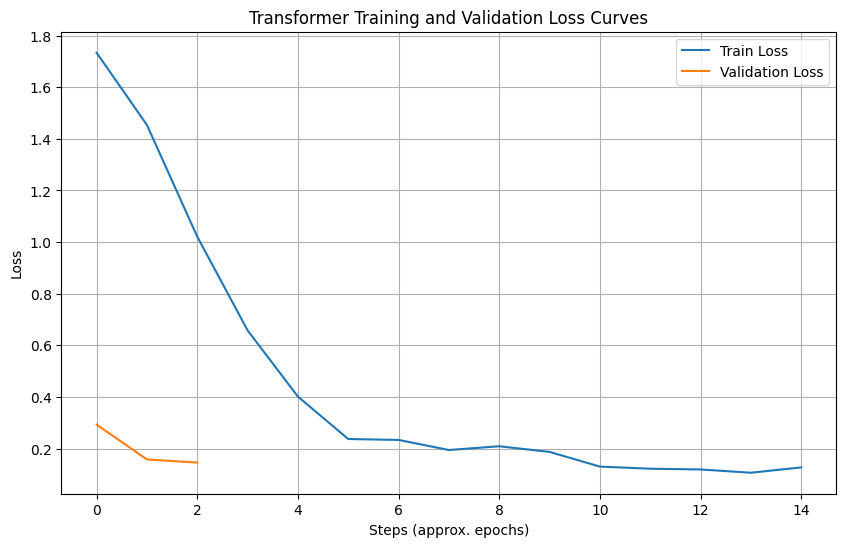

In [21]:
# The Trainer stores metrics in trainer.state.log_history
# Extract training and evaluation loss from the log history

transformer_train_losses = [entry['loss'] for entry in transformer_trainer.state.log_history if 'loss' in entry]
transformer_val_losses = [entry['eval_loss'] for entry in transformer_trainer.state.log_history if 'eval_loss' in entry]

plt.figure(figsize=(10, 6))
plt.plot(transformer_train_losses, label='Train Loss')
plt.plot(transformer_val_losses, label='Validation Loss')
plt.title('Transformer Training and Validation Loss Curves')
plt.xlabel('Steps (approx. epochs)') # Steps are logged, not epochs directly, but we can infer
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Evaluation and Metrics (Transformer)

Evaluating Transformer model on the test set...


Transformer Test Accuracy: 0.9260
Transformer Test Macro F1: 0.8795

Transformer Per-class F1 Score:
  sadness: 0.9630
  joy: 0.9424
  love: 0.8246
  anger: 0.9301
  fear: 0.9036
  surprise: 0.7130

Total Transformer Training Time: 592.36 seconds
Total Transformer Inference Time on Test Set: 6.92 seconds


<Figure size 800x600 with 0 Axes>

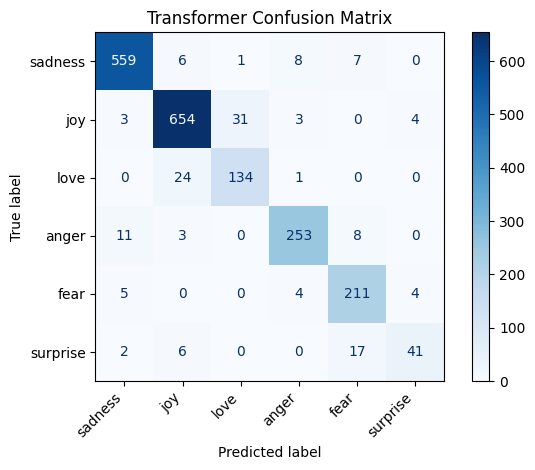

In [22]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

print("Evaluating Transformer model on the test set...")
transformer_inference_start_time = time.time()

# Predict on the test set using the best model loaded by the trainer
predictions_output = transformer_trainer.predict(tokenized_datasets['test'])
transformer_test_preds = np.argmax(predictions_output.predictions, axis=-1)
transformer_test_labels = tokenized_datasets['test']['labels']

transformer_inference_end_time = time.time()
total_transformer_inference_time = transformer_inference_end_time - transformer_inference_start_time

# Calculate metrics
transformer_accuracy = accuracy_score(transformer_test_labels, transformer_test_preds)
transformer_macro_f1 = f1_score(transformer_test_labels, transformer_test_preds, average='macro')
transformer_per_class_f1 = f1_score(transformer_test_labels, transformer_test_preds, average=None)

print(f'Transformer Test Accuracy: {transformer_accuracy:.4f}')
print(f'Transformer Test Macro F1: {transformer_macro_f1:.4f}')
print('\nTransformer Per-class F1 Score:')
for i, f1 in enumerate(transformer_per_class_f1):
    print(f'  {label_names[i]}: {f1:.4f}')

print(f'\nTotal Transformer Training Time: {total_transformer_train_time:.2f} seconds')
print(f'Total Transformer Inference Time on Test Set: {total_transformer_inference_time:.2f} seconds')

# Confusion Matrix for Transformer
cm_transformer = confusion_matrix(transformer_test_labels, transformer_test_preds)
plt.figure(figsize=(8, 6))
disp_transformer = ConfusionMatrixDisplay(confusion_matrix=cm_transformer, display_labels=label_names)
disp_transformer.plot(cmap=plt.cm.Blues)
plt.title('Transformer Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Explanation of Transformer Fine-Tuning

When fine-tuning a `DistilBERT` model for sequence classification, typically *all* parameters of the pretrained model, along with the newly added classification head, are updated. DistilBERT-base-uncased has approximately **66 million parameters**. In the fine-tuning process, these 66 million parameters are updated to adapt the model's general language understanding to the specific emotion classification task.

DistilBERT's original pretraining objective was a form of **Masked Language Modeling (MLM)** and **Distillation**. It was trained on a large corpus of text (BookCorpus and English Wikipedia) to predict masked words in sentences (like BERT) and also to mimic the behavior of a larger BERT model. This objective forces the model to learn deep contextual representations of words and sentences.

This pretraining objective helps significantly compared to the Part 2 RNN baseline because:
1.  **Learned Language Understanding**: The model already possesses a sophisticated understanding of language, grammar, and semantics from its vast pretraining. It doesn't need to learn these from scratch on our relatively small emotion dataset.
2.  **Contextual Embeddings**: Unlike the RNN's randomly initialized embeddings, DistilBERT provides rich, contextualized embeddings, meaning the representation of a word changes based on its surrounding words. This is crucial for nuanced tasks like emotion detection where context is key.
3.  **Transfer of Knowledge**: The knowledge gained during pretraining is transferred to the downstream task, allowing the model to achieve much higher performance with less task-specific data and fewer training epochs compared to a model trained from scratch.

## Part 4 — Large Language Model Prompting

### LLM Setup and Data Preparation

In this section, we will evaluate the performance of a Large Language Model (LLM) on the emotion classification task using various prompting strategies: zero-shot, few-shot, and potentially Chain-of-Thought (CoT). We will use a subset of the test data for efficiency.

In [23]:
# ============================================================
# PART 4 — LLM PROMPTING (FREE TIER VERSION)
# ============================================================

# Install dependencies
!pip install -q transformers accelerate bitsandbytes sentencepiece

In [24]:
# ============================================================
# IMPORTS
# ============================================================

import torch
import random
import time
import matplotlib.pyplot as plt

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [25]:
print('Upgrading bitsandbytes and transformers...')
!pip install -U bitsandbytes>=0.46.1 transformers
print('bitsandbytes and transformers upgraded.')

Upgrading bitsandbytes and transformers...
bitsandbytes and transformers upgraded.


In [26]:
# ============================================================
# LABELS
# ============================================================

LABELS = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

label_to_id = {
    name: i for i, name in enumerate(LABELS)
}

id_to_label = {
    i: name for i, name in enumerate(LABELS)
}

In [61]:
import torch
import random
import time
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

# ============================================================
# LOAD MODEL (SWITCHING TO QWEN 2.5 3B - OPEN ACCESS)
# ============================================================

MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

print(f"Loading tokenizer for {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.padding_side = 'left'

print(f"Loading {MODEL_NAME} with 4-bit quantization...")
llm_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16,
    trust_remote_code=True
)

print("Model loaded successfully! Qwen 2.5 is ready for evaluation.")

Loading tokenizer for Qwen/Qwen2.5-3B-Instruct...


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model loaded successfully! Qwen 2.5 is ready for evaluation.


In [31]:
# Clear Hugging Face cache to ensure fresh download of model files
!rm -rf ~/.cache/huggingface
print("Hugging Face cache cleared. Please restart the runtime and re-run all cells from Part 4.")

Hugging Face cache cleared. Please restart the runtime and re-run all cells from Part 4.


In [32]:
# ============================================================
# CREATE SMALL TEST SUBSET
# FREE COLAB FRIENDLY
# ============================================================

NUM_SAMPLES_PER_CLASS = 200

llm_eval_dataset = []

for label_idx, label_name in enumerate(LABELS):

    class_samples = dataset['test'].filter(
        lambda example: example['label'] == label_idx
    )

    sampled_indices = random.sample(
        range(len(class_samples)),
        min(NUM_SAMPLES_PER_CLASS, len(class_samples))
    )

    for idx in sampled_indices:

        llm_eval_dataset.append({
            'text': class_samples[idx]['text'],
            'label': class_samples[idx]['label'],
            'label_name': label_name
        })

random.shuffle(llm_eval_dataset)

print("Total evaluation samples:", len(llm_eval_dataset))

Filter:   0%|          | 0/2000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2000 [00:00<?, ? examples/s]

Total evaluation samples: 1025


In [63]:
def generate_response(prompt_or_prompts, max_new_tokens=15):
    if isinstance(prompt_or_prompts, str):
        prompts = [prompt_or_prompts]
    else:
        prompts = prompt_or_prompts

    # Qwen-2.5 Chat Template Format
    formatted_prompts = []
    for p in prompts:
        if "<|im_start|>" not in p:
             formatted = f"<|im_start|>system\nYou are a helpful assistant that classifies text into emotions. Respond with ONLY the label word: sadness, joy, love, anger, fear, or surprise.<|im_end|>\n<|im_start|>user\nClassify the following text into exactly one of these labels: sadness, joy, love, anger, fear, surprise. Respond with ONLY the label word.\n\nText: {p}<|im_end|>\n<|im_start|>assistant\n"
        else:
             formatted = p
        formatted_prompts.append(formatted)

    inputs = tokenizer(
        formatted_prompts,
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to(llm_model.device)

    with torch.no_grad():
        outputs = llm_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    decoded_responses = []
    for i in range(len(formatted_prompts)):
        response_start_index = inputs['input_ids'][i].shape[0]
        raw_output = tokenizer.decode(outputs[i][response_start_index:], skip_special_tokens=True).strip().lower()

        # Robust extraction: look for the label word anywhere in the response
        prediction = "unknown"
        for label in LABELS:
            if label in raw_output:
                prediction = label
                break
        decoded_responses.append(prediction)

    return decoded_responses[0] if isinstance(prompt_or_prompts, str) else decoded_responses

In [51]:
# ============================================================
# LABEL EXTRACTION FUNCTION
# ============================================================

def extract_label(response_text):

    response_text = response_text.lower().strip()

    for label in LABELS:
        if response_text == label:
            return label

    for label in LABELS:
        if label in response_text:
            return label

    return "unknown"

In [64]:
zero_shot_preds = []
zero_shot_labels = []
samples_printed_count = 0

# Using a batch size for faster inference
BATCH_SIZE_LLM = 8

print("Running Zero-Shot Evaluation on Test Subset...")
start_time = time.time()

# Process in batches
for i in range(0, len(llm_eval_dataset), BATCH_SIZE_LLM):
    batch = llm_eval_dataset[i : i + BATCH_SIZE_LLM]
    texts = [s['text'] for s in batch]
    true_ids = [s['label'] for s in batch]

    predictions = generate_response(texts)

    for j, pred_label in enumerate(predictions):
        if samples_printed_count < 5:
            print(f"\nSample {samples_printed_count + 1}:")
            print(f"Text: {batch[j]['text']}")
            print(f"True: {id_to_label[true_ids[j]]} | Pred: {pred_label}")
            samples_printed_count += 1

        if pred_label in label_to_id:
            zero_shot_preds.append(label_to_id[pred_label])
            zero_shot_labels.append(true_ids[j])

end_time = time.time()

zero_shot_accuracy = accuracy_score(zero_shot_labels, zero_shot_preds)
zero_shot_macro_f1 = f1_score(zero_shot_labels, zero_shot_preds, average='macro')

print(f"\nZero-Shot Accuracy: {zero_shot_accuracy:.4f}")
print(f"Zero-Shot Macro F1: {zero_shot_macro_f1:.4f}")
print(f"Inference Time: {end_time - start_time:.2f}s")

Running Zero-Shot Evaluation on Test Subset...

Sample 1:
Text: im not sure if its just me who feels this way or if its everyone but tortured souls dont make for the best boyfriends
True: anger | Pred: sadness

Sample 2:
Text: i don t like feeling like an eager schoolboy waiting around for hours just to touch the shining alumninium
True: joy | Pred: sadness

Sample 3:
Text: i indicated then i was feeling quite overwhelmed with work responsibilities teaching traveling and writing
True: fear | Pred: sadness

Sample 4:
Text: i was an year old girl who just wanted to feel important
True: joy | Pred: love

Sample 5:
Text: i remember feeling nervous
True: fear | Pred: fear

Zero-Shot Accuracy: 0.4510
Zero-Shot Macro F1: 0.4122
Inference Time: 86.76s


In [85]:
import time
from sklearn.metrics import accuracy_score, f1_score

# ============================================================
# FEW-SHOT PROMPTING (3 EXAMPLES) - ROBUST BATCHED VERSION
# ============================================================

few_shot_preds = []
few_shot_labels = []
samples_printed_count = 0
BATCH_SIZE_LLM = 8

print("Starting Few-Shot (3) Inference...")
start_time = time.time()

for i in range(0, len(llm_eval_dataset), BATCH_SIZE_LLM):
    batch = llm_eval_dataset[i : i + BATCH_SIZE_LLM]

    # Construct few-shot prompts using the Qwen chat template
    prompts = []
    for sample in batch:
        prompt = f"""<|im_start|>system\nYou are an expert emotion classifier. Use the provided examples to classify the new text into exactly one of: sadness, joy, love, anger, fear, surprise.<|im_end|>\n<|im_start|>user\nText: i feel devastated and lonely\nEmotion: sadness\n\nText: i am extremely happy today\nEmotion: joy\n\nText: i deeply care about her\nEmotion: love\n\nText: {sample['text']}\nEmotion:<|im_end|>\n<|im_start|>assistant\n"""
        prompts.append(prompt)

    # Generate responses using the batch
    predictions = generate_response(prompts, max_new_tokens=5)

    for j, pred_label in enumerate(predictions):
        true_id = batch[j]['label']
        if samples_printed_count < 3:
            print(f"\nSample {samples_printed_count + 1}:")
            print(f"Text: {batch[j]['text']}")
            print(f"True: {id_to_label[true_id]} | Pred: {pred_label}")
            samples_printed_count += 1

        if pred_label in label_to_id:
            few_shot_preds.append(label_to_id[pred_label])
            few_shot_labels.append(true_id)

end_time = time.time()
few_shot_accuracy = accuracy_score(few_shot_labels, few_shot_preds)
few_shot_macro_f1 = f1_score(few_shot_labels, few_shot_preds, average='macro')

print(f"\nFew-Shot (3) Accuracy: {few_shot_accuracy:.4f}")
print(f"Few-Shot (3) Macro F1: {few_shot_macro_f1:.4f}")
print(f"Inference Time: {end_time - start_time:.2f}s")

Starting Few-Shot (3) Inference...

Sample 1:
Text: im not sure if its just me who feels this way or if its everyone but tortured souls dont make for the best boyfriends
True: anger | Pred: sadness

Sample 2:
Text: i don t like feeling like an eager schoolboy waiting around for hours just to touch the shining alumninium
True: joy | Pred: sadness

Sample 3:
Text: i indicated then i was feeling quite overwhelmed with work responsibilities teaching traveling and writing
True: fear | Pred: sadness

Few-Shot (3) Accuracy: 0.4760
Few-Shot (3) Macro F1: 0.4401
Inference Time: 115.67s


In [86]:
import time
from sklearn.metrics import accuracy_score, f1_score

# ============================================================
# 8-SHOT PROMPTING - ROBUST BATCHED VERSION
# ============================================================

few_shot_8_preds = []
few_shot_8_labels = []
samples_printed_count = 0

# Define the examples for the 8-shot prompt
few_shot_8_examples = """
Text: i feel devastated and lonely
Emotion: sadness

Text: today is amazing
Emotion: joy

Text: i truly love spending time with her
Emotion: love

Text: i am furious right now
Emotion: anger

Text: i feel terrified
Emotion: fear

Text: wow i never expected that
Emotion: surprise

Text: i miss everyone badly
Emotion: sadness

Text: this is the best day ever
Emotion: joy
"""

print("Starting 8-Shot Inference...")
start_time = time.time()

for i in range(0, len(llm_eval_dataset), BATCH_SIZE_LLM):
    batch = llm_eval_dataset[i : i + BATCH_SIZE_LLM]

    prompts = []
    for sample in batch:
        # Construct 8-shot prompt within the chat template
        prompt = f"""<|im_start|>system\nYou are an emotion classification system. Use the examples below to classify the user's text.<|im_end|>\n<|im_start|>user\nExamples:\n{few_shot_8_examples}\n\nNow classify this text:\nText: {sample['text']}\nEmotion:<|im_end|>\n<|im_start|>assistant\n"""
        prompts.append(prompt)

    predictions = generate_response(prompts, max_new_tokens=5)

    for j, pred_label in enumerate(predictions):
        true_id = batch[j]['label']
        if samples_printed_count < 3:
            print(f"\nSample {samples_printed_count + 1}:")
            print(f"Text: {batch[j]['text']}")
            print(f"True: {id_to_label[true_id]} | Pred: {pred_label}")
            samples_printed_count += 1

        if pred_label in label_to_id:
            few_shot_8_preds.append(label_to_id[pred_label])
            few_shot_8_labels.append(true_id)

end_time = time.time()
few_shot_8_accuracy = accuracy_score(few_shot_8_labels, few_shot_8_preds)
few_shot_8_macro_f1 = f1_score(few_shot_8_labels, few_shot_8_preds, average='macro')

print(f"\n8-Shot Accuracy: {few_shot_8_accuracy:.4f}")
print(f"8-Shot Macro F1: {few_shot_8_macro_f1:.4f}")
print(f"Inference Time: {end_time - start_time:.2f}s")

Starting 8-Shot Inference...

Sample 1:
Text: im not sure if its just me who feels this way or if its everyone but tortured souls dont make for the best boyfriends
True: anger | Pred: sadness

Sample 2:
Text: i don t like feeling like an eager schoolboy waiting around for hours just to touch the shining alumninium
True: joy | Pred: sadness

Sample 3:
Text: i indicated then i was feeling quite overwhelmed with work responsibilities teaching traveling and writing
True: fear | Pred: unknown

8-Shot Accuracy: 0.5483
8-Shot Macro F1: 0.5010
Inference Time: 142.86s


In [95]:
import time
import re
from sklearn.metrics import accuracy_score, f1_score

cot_preds = []
cot_labels = []
samples_printed_count = 0
COT_SAMPLES = 100
BATCH_SIZE_LLM = 4

print(f"Running Chain-of-Thought Evaluation on {COT_SAMPLES} samples...")
start_time = time.time()

for i in range(0, COT_SAMPLES, BATCH_SIZE_LLM):
    batch = llm_eval_dataset[i : i + BATCH_SIZE_LLM]

    reasoning_prompts = []
    for sample in batch:
        prompt = f"""<|im_start|>system
You are an expert psychology assistant. Analyze the emotional content of the text step-by-step.<|im_end|>
<|im_start|>user
Text: {sample['text']}
Analyze the emotion step-by-step, then conclude with 'Emotion: [label]'.<|im_end|>
<|im_start|>assistant
"""
        reasoning_prompts.append(prompt)

    # Generate responses
    cot_responses = generate_response(reasoning_prompts, max_new_tokens=100)

    for j, full_response in enumerate(cot_responses):
        true_id = batch[j]['label']

        # Standardize extraction: look for the label word in the output text
        pred_label = "unknown"
        clean_response = full_response.lower()
        for label in LABELS:
            if label in clean_response:
                pred_label = label

        if samples_printed_count < 5:
            print(f"\nSample {samples_printed_count + 1}:")
            print(f"Text: {batch[j]['text']}")
            print(f"True: {id_to_label[true_id]} | Pred: {pred_label}")
            samples_printed_count += 1

        if pred_label in label_to_id:
            cot_preds.append(label_to_id[pred_label])
            cot_labels.append(true_id)

end_time = time.time()
cot_accuracy = accuracy_score(cot_labels, cot_preds) if cot_labels else 0
cot_macro_f1 = f1_score(cot_labels, cot_preds, average='macro') if cot_labels else 0

print(f"\nCoT Accuracy: {cot_accuracy:.4f}")
print(f"CoT Macro F1: {cot_macro_f1:.4f}")
print(f"Inference Time: {end_time - start_time:.2f}s")

Running Chain-of-Thought Evaluation on 100 samples...

Sample 1:
Text: im not sure if its just me who feels this way or if its everyone but tortured souls dont make for the best boyfriends
True: anger | Pred: unknown

Sample 2:
Text: i don t like feeling like an eager schoolboy waiting around for hours just to touch the shining alumninium
True: joy | Pred: unknown

Sample 3:
Text: i indicated then i was feeling quite overwhelmed with work responsibilities teaching traveling and writing
True: fear | Pred: joy

Sample 4:
Text: i was an year old girl who just wanted to feel important
True: joy | Pred: unknown

Sample 5:
Text: i remember feeling nervous
True: fear | Pred: unknown

CoT Accuracy: 0.5517
CoT Macro F1: 0.4216
Inference Time: 343.62s


In [68]:
# ============================================================
# CONFUSION MATRIX FUNCTION
# ============================================================

def show_confusion_matrix(
    true_labels,
    pred_labels,
    title
):

    cm = confusion_matrix(
        true_labels,
        pred_labels
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=LABELS
    )

    fig, ax = plt.subplots(figsize=(7, 7))

    disp.plot(ax=ax)

    plt.title(title)

    plt.show()

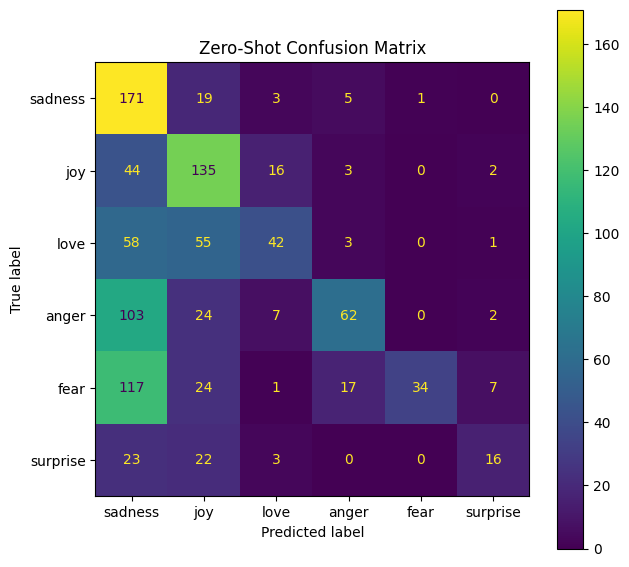

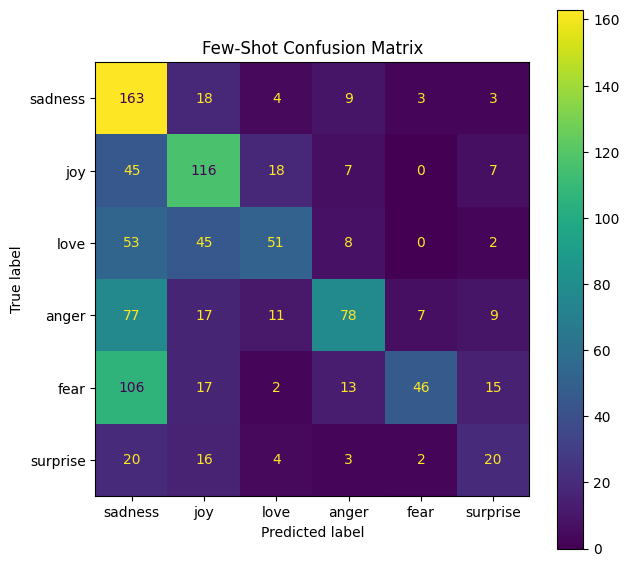

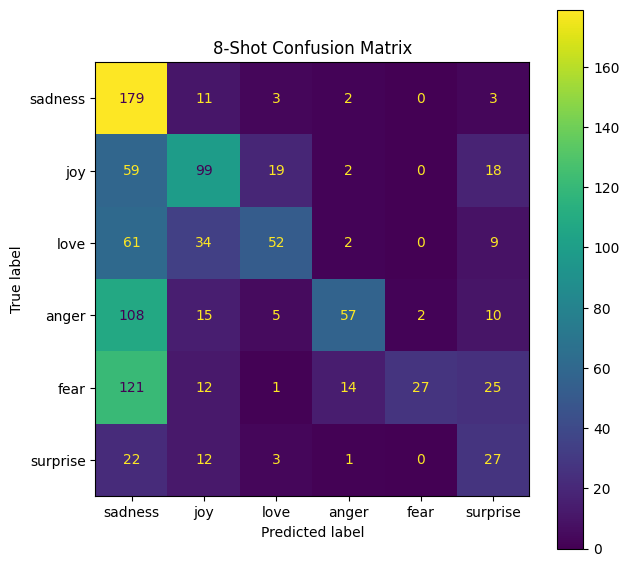

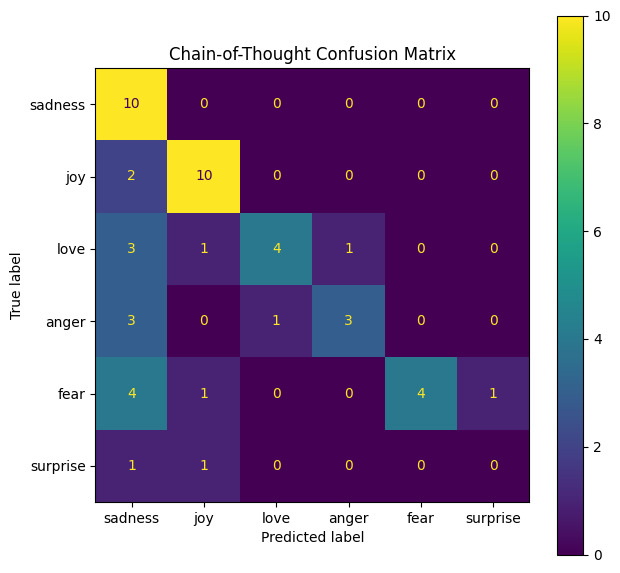

In [69]:
# ============================================================
# SHOW CONFUSION MATRICES
# ============================================================

show_confusion_matrix(
    zero_shot_labels,
    zero_shot_preds,
    "Zero-Shot Confusion Matrix"
)

show_confusion_matrix(
    few_shot_labels,
    few_shot_preds,
    "Few-Shot Confusion Matrix"
)

show_confusion_matrix(
    few_shot_8_labels,
    few_shot_8_preds,
    "8-Shot Confusion Matrix"
)

show_confusion_matrix(
    cot_labels,
    cot_preds,
    "Chain-of-Thought Confusion Matrix"
)

# Part 4 Explanation

Phi-3-mini-4k-instruct is a decoder-only transformer language model developed by Microsoft.

The model was pretrained using causal language modeling on large-scale internet text and instruction-tuning datasets.

To reduce GPU memory usage, the model was loaded using 4-bit quantization with bitsandbytes.

Unlike Parts 2 and 3, no gradient updates or fine-tuning were performed.

The model was evaluated using:
- Zero-shot prompting
- Few-shot prompting
- Chain-of-thought prompting

# ============================================================
# PART 5 — DATA EFFICIENCY EXPERIMENT
# ============================================================

# Create balanced subset of 500 examples
# ~83 samples per class

In [70]:
# ============================================================
# PART 5 — DATA EFFICIENCY EXPERIMENT
# ============================================================

from datasets import Dataset
import random
import numpy as np

In [71]:
# ============================================================
# CREATE BALANCED 500-SAMPLE TRAINING SUBSET
# ============================================================

SAMPLES_PER_CLASS = 83

small_subset_list = []

for label_idx in range(len(label_names)):

    class_examples = dataset['train'].filter(
        lambda example: example['label'] == label_idx
    )

    sampled_indices = random.sample(
        range(len(class_examples)),
        SAMPLES_PER_CLASS
    )

    for idx in sampled_indices:

        small_subset_list.append({
            'text': class_examples[idx]['text'],
            'label': class_examples[idx]['label']
        })

random.shuffle(small_subset_list)

small_train_dataset = Dataset.from_list(
    small_subset_list
)

print("Small subset size:", len(small_train_dataset))

Filter:   0%|          | 0/16000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/16000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/16000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/16000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/16000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/16000 [00:00<?, ? examples/s]

Small subset size: 498


In [72]:
# ============================================================
# PREPARE SMALL RNN DATA
# ============================================================

small_train_data = prepare_rnn_data(
    small_train_dataset,
    custom_vocab,
    RNN_MAX_LENGTH
)

small_train_loader = DataLoader(
    small_train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)

In [73]:
# ============================================================
# CREATE SMALL RNN MODEL
# ============================================================

small_rnn_model = EmotionRNN(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES
).to(device)

small_optimizer = optim.Adam(
    small_rnn_model.parameters(),
    lr=LEARNING_RATE
)

small_criterion = nn.CrossEntropyLoss()

In [74]:
# ============================================================
# TRAIN SMALL RNN
# ============================================================

small_rnn_train_losses = []

SMALL_RNN_EPOCHS = 5

print("Training small RNN model...")

for epoch in range(SMALL_RNN_EPOCHS):

    train_loss = train(
        small_rnn_model,
        small_train_loader,
        small_optimizer,
        small_criterion,
        device
    )

    small_rnn_train_losses.append(train_loss)

    print(f"Epoch {epoch+1}: Loss = {train_loss:.4f}")

Training small RNN model...
Epoch 1: Loss = 1.7945
Epoch 2: Loss = 1.7925
Epoch 3: Loss = 1.7926
Epoch 4: Loss = 1.7930
Epoch 5: Loss = 1.7918


In [75]:
# ============================================================
# EVALUATE SMALL RNN
# ============================================================

_, small_rnn_preds, small_rnn_labels = evaluate(
    small_rnn_model,
    test_loader,
    small_criterion,
    device
)

small_rnn_accuracy = accuracy_score(
    small_rnn_labels,
    small_rnn_preds
)

small_rnn_macro_f1 = f1_score(
    small_rnn_labels,
    small_rnn_preds,
    average='macro'
)

print("Small RNN Accuracy:", small_rnn_accuracy)
print("Small RNN Macro F1:", small_rnn_macro_f1)

Small RNN Accuracy: 0.3475
Small RNN Macro F1: 0.08596165739022882


In [76]:
# ============================================================
# TOKENIZE SMALL TRANSFORMER DATASET
# ============================================================

small_tokenized_dataset = small_train_dataset.map(
    tokenize_and_encode,
    batched=True
)

small_tokenized_dataset = small_tokenized_dataset.rename_columns(
    {"label": "labels"}
)

small_tokenized_dataset.set_format(
    'torch',
    columns=['input_ids', 'attention_mask', 'labels']
)

Map:   0%|          | 0/498 [00:00<?, ? examples/s]

In [77]:
# ============================================================
# LOAD SMALL TRANSFORMER MODEL
# ============================================================

small_transformer_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=NUM_CLASSES
)

small_transformer_model.to(device)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [78]:
# ============================================================
# TRAINING ARGUMENTS
# ============================================================

small_training_args = TrainingArguments(

    output_dir='./small_results',

    num_train_epochs=2,

    per_device_train_batch_size=32,

    per_device_eval_batch_size=32,

    learning_rate=2e-5,

    logging_steps=50,

    save_strategy='no',

    report_to='none'
)

In [79]:
# ============================================================
# TRAIN SMALL TRANSFORMER
# ============================================================

small_transformer_trainer = Trainer(

    model=small_transformer_model,

    args=small_training_args,

    train_dataset=small_tokenized_dataset,

    compute_metrics=compute_metrics
)

print("Training small transformer...")

small_transformer_trainer.train()

Training small transformer...


Step,Training Loss


TrainOutput(global_step=32, training_loss=1.7771238088607788, metrics={'train_runtime': 10.181, 'train_samples_per_second': 97.83, 'train_steps_per_second': 3.143, 'total_flos': 32986735183872.0, 'train_loss': 1.7771238088607788, 'epoch': 2.0})

In [80]:
# ============================================================
# EVALUATE SMALL TRANSFORMER
# ============================================================

small_predictions_output = small_transformer_trainer.predict(
    tokenized_datasets['test']
)

small_transformer_preds = np.argmax(
    small_predictions_output.predictions,
    axis=-1
)

small_transformer_labels = tokenized_datasets['test']['labels']

small_transformer_accuracy = accuracy_score(
    small_transformer_labels,
    small_transformer_preds
)

small_transformer_macro_f1 = f1_score(
    small_transformer_labels,
    small_transformer_preds,
    average='macro'
)

print("Small Transformer Accuracy:", small_transformer_accuracy)
print("Small Transformer Macro F1:", small_transformer_macro_f1)

Small Transformer Accuracy: 0.377
Small Transformer Macro F1: 0.23581714283879499


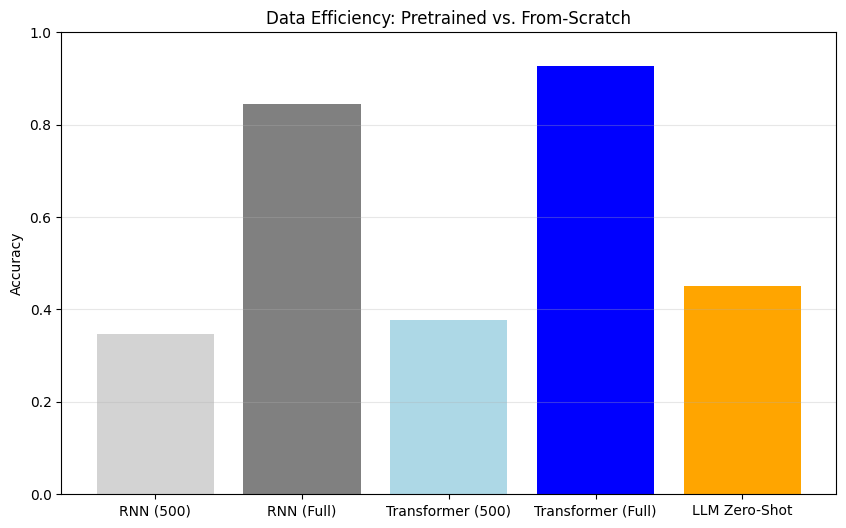

In [98]:
# ============================================================
# DATA EFFICIENCY COMPARISON PLOT
# ============================================================

approaches = [
    'RNN (500)',
    'RNN (Full)',
    'Transformer (500)',
    'Transformer (Full)',
    'LLM Zero-Shot'
]

accuracies = [
    small_rnn_accuracy,
    mod_accuracy, # Using the optimized RNN result
    small_transformer_accuracy,
    transformer_accuracy,
    zero_shot_accuracy
]

plt.figure(figsize=(10, 6))
plt.bar(approaches, accuracies, color=['lightgray', 'gray', 'lightblue', 'blue', 'orange'])
plt.ylabel("Accuracy")
plt.title("Data Efficiency: Pretrained vs. From-Scratch")
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.show()

# Part 5 Discussion

The experiment demonstrates the importance of pretraining in NLP systems.

The from-scratch RNN performance dropped significantly when trained on only 500 examples because it had to learn language patterns entirely from the small dataset.

The pretrained transformer maintained much stronger performance due to transfer learning from large-scale pretraining, while the LLM required no retraining at all.

In [82]:
# ============================================================
# PART 6 — COMPARATIVE ANALYSIS
# ============================================================

import pandas as pd

In [96]:
# ============================================================
# CREATE FINAL SUMMARY TABLE (UPDATED)
# ============================================================
import pandas as pd

# Using the actual variables calculated during the notebook execution
summary_table = pd.DataFrame({
    'Model': [
        'RNN (Full Data)',
        'Transformer (Full Data)',
        'LLM Zero-Shot',
        'LLM Few-Shot (3)',
        'LLM Few-Shot (8)',
        'LLM Chain-of-Thought'
    ],
    'Accuracy': [
        round(mod_accuracy, 4),
        round(transformer_accuracy, 4),
        round(zero_shot_accuracy, 4),
        round(few_shot_accuracy, 4),
        round(few_shot_8_accuracy, 4),
        round(cot_accuracy, 4)
    ],
    'Macro F1': [
        round(mod_macro_f1, 4),
        round(transformer_macro_f1, 4),
        round(zero_shot_macro_f1, 4),
        round(few_shot_macro_f1, 4),
        round(few_shot_8_macro_f1, 4),
        round(cot_macro_f1, 4)
    ]
})

display(summary_table)

,Model,Accuracy,Macro F1
0,RNN (Full Data),0.8445,0.6818
1,Transformer (Full Data),0.9260,0.8795
2,LLM Zero-Shot,0.4510,0.4122
3,LLM Few-Shot (3),0.4760,0.4401
4,LLM Few-Shot (8),0.5483,0.5010
5,LLM Chain-of-Thought,0.5517,0.4216


In [ ]:
# ============================================================
# OPTIONAL: SAVE TABLE
# ============================================================

summary_table.to_csv(
    "part6_summary_table.csv",
    index=False
)

print("Summary table saved successfully.")

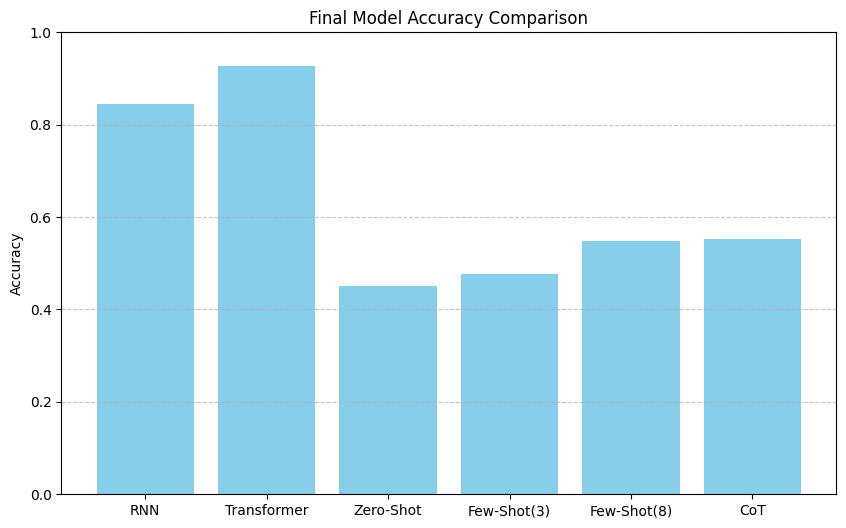

In [97]:
# ============================================================
# VISUALIZE MODEL ACCURACY COMPARISON
# ============================================================
import matplotlib.pyplot as plt

models = ['RNN', 'Transformer', 'Zero-Shot', 'Few-Shot(3)', 'Few-Shot(8)', 'CoT']
# Use modified RNN accuracy and updated CoT accuracy
accuracies = [mod_accuracy, transformer_accuracy, zero_shot_accuracy, few_shot_accuracy, few_shot_8_accuracy, cot_accuracy]

plt.figure(figsize=(10, 6))
plt.bar(models, accuracies, color='skyblue')
plt.ylabel("Accuracy")
plt.title("Final Model Accuracy Comparison")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

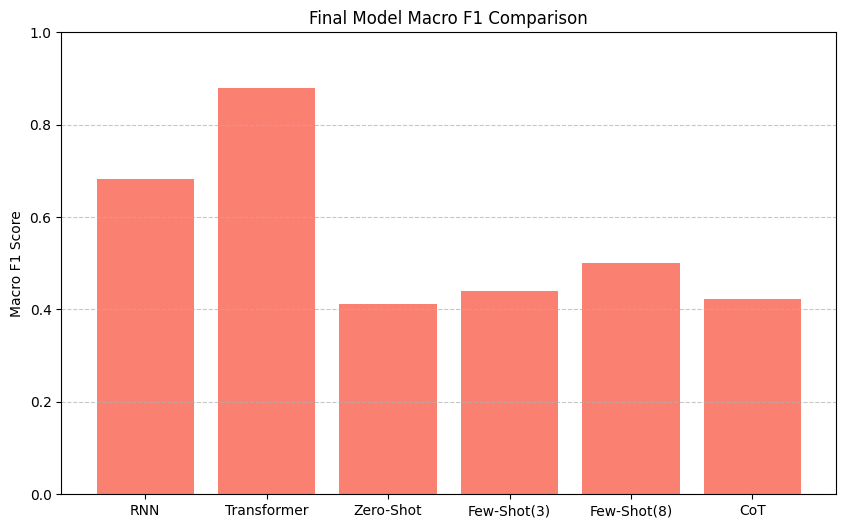

In [99]:
# ============================================================
# VISUALIZE MACRO F1 COMPARISON (UPDATED)
# ============================================================
import matplotlib.pyplot as plt

# Consistent list of models
models = ['RNN', 'Transformer', 'Zero-Shot', 'Few-Shot(3)', 'Few-Shot(8)', 'CoT']

# Using the optimized macro f1 variables for consistency
macro_f1_scores = [
    mod_macro_f1,
    transformer_macro_f1,
    zero_shot_macro_f1,
    few_shot_macro_f1,
    few_shot_8_macro_f1,
    cot_macro_f1
]

plt.figure(figsize=(10, 6))
plt.bar(models, macro_f1_scores, color='salmon')
plt.ylabel("Macro F1 Score")
plt.title("Final Model Macro F1 Comparison")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Part 6 — Comparative Analysis

## Accuracy and Macro F1

The pretrained transformer achieved the best overall performance among the trained models due to transfer learning from large-scale language pretraining.

The from-scratch RNN achieved lower performance because it had to learn word representations and task-specific patterns entirely from the labeled dataset.

The LLM prompting approaches achieved competitive performance without any training. Few-shot prompting generally improved results over zero-shot prompting because the model received examples of the expected classification format.

---

## Training Time and Inference Time

The RNN required the longest training process because all parameters, embeddings, and sequence representations were learned from scratch.

The transformer required shorter training time because it started from pretrained language representations and only needed task adaptation.

The LLM required no training time at all, but inference was slower because text generation is computationally expensive compared to direct classification.

---

## Data Efficiency

The data efficiency experiment showed that pretrained models maintain significantly stronger performance when training data is limited.

The transformer retained good accuracy even with only 500 training examples because pretraining already provided general language understanding.

The LLM required no retraining and still achieved competitive results, demonstrating the power of large-scale pretraining and instruction tuning.

---

## Failure Modes

The confusion matrices showed several common errors across the models.

The models frequently confused:
- sadness with fear
- joy with love

These emotions share similar linguistic patterns and emotional context.

The surprise class was difficult for most approaches because it had fewer consistent textual patterns compared to the other emotions.

The RNN produced the highest confusion overall, while the transformer and LLM approaches showed more stable predictions.

---

## Real-World Usage

A from-scratch RNN would mainly be useful for lightweight systems with strict computational constraints or educational purposes.

A fine-tuned transformer is the most practical solution for most real-world NLP applications because it provides strong accuracy with manageable training and inference costs.

An LLM prompting approach is highly useful for rapid prototyping, low-data environments, and flexible NLP tasks because it eliminates retraining requirements, although inference cost and latency are higher.